# Анализ системы метрик приложения Procrastinate Pro+

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

Наши задачи:

- провести анализ юнит-экономики продукта в динамике за первые 28 дней
- разобраться в причинах стагнации выручки
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости
- дать рекомендации отделу маркетинга

### Данные

В нашем распоряжении есть данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

Загрузите данные и получите основную информацию о них. Проведите необходимую предобработку. Основную информацию о данных и предобработке зафиксируйте в кратком промежуточном выводе.

In [73]:
# импорты библиотек
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

In [ ]:
# загрузка данных 
df_costs = pd.read_csv('секретная_информация/ppro_costs.csv', parse_dates = ['dt'])
df_orders = pd.read_csv('секретная_информация/ppro_orders.csv', parse_dates = ['event_dt'])
df_visits = pd.read_csv('секретная_информация/ppro_visits.csv', parse_dates = ['session_start', 'session_end'])


In [75]:
# для проверки корректности загрузим первые пять строк
display(df_costs.head(5))
display(df_orders.head(5))
display(df_visits.head(5))


,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


In [76]:
# проверим данные 
# соответствие типов
display(df_costs.dtypes)
display(df_orders.dtypes)
display(df_visits.dtypes)

dt         datetime64[ns]
channel            object
costs             float64
dtype: object

user_id              int64
event_dt    datetime64[ns]
revenue            float64
dtype: object

user_id                   int64
region                   object
device                   object
channel                  object
session_start    datetime64[ns]
session_end      datetime64[ns]
dtype: object

In [77]:
# добавим необходимые периоды
df_visits['visit_day'] = df_visits['session_start'].dt.to_period('D')
df_visits['visit_month'] = df_visits['session_start'].dt.to_period('M')

df_orders['purchase_day'] = df_orders['event_dt'].dt.to_period('D')

In [78]:
# проверим пропуски
display(df_costs.isna().sum())
display(df_orders.isna().sum())
display(df_visits.isna().sum())

dt         0
channel    0
costs      0
dtype: int64

user_id         0
event_dt        0
revenue         0
purchase_day    0
dtype: int64

user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
visit_day        0
visit_month      0
dtype: int64

In [79]:
# проверим дубликаты
display(df_costs.duplicated().sum())
display(df_orders.duplicated().sum())
display(df_visits.duplicated().sum())


np.int64(0)

np.int64(0)

np.int64(0)

По результатам проверки типы соответствуют данным, пропуски и дубликаты не обнаружены. 

## Подготовка данных к когортному анализу

Подготовим данные к когортному анализу, чтобы изучить окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдём дату первой сессии (дата привлечения, `first_dt`), канал привлечения (`first_channel`) и стоимость привлечения (`cac`). Результаты сохраним в новой таблице, например, `profiles`.

Добавим к данным с событиями и покупками информацию о первом источнике привлечения и дате привлечения пользователя из созданной таблицы.   
После этого рассчитаем дневной лайфтайм для каждого события или покупки и добавим в таблицу в виде целого числа. При проведении когортного анализа используем информацию о первом источнике привлечения пользователя.

In [80]:
# уберем из данных последний месяц
last_month = df_visits['session_start'].dt.to_period('M').max().to_timestamp()

df_visits = df_visits[df_visits['session_start'] < last_month]
df_orders = df_orders[df_orders['event_dt'] < last_month]
df_costs = df_costs[df_costs['dt'] < last_month]


In [81]:
# сгруппируем данные, что бы найти первую дату активности и первый канал привлечения, подготовить датасеты для слияния
# а так же посчитаем выручку и затраты на маркетинг



df_channel_grouped = df_visits.sort_values(by='session_start')\
    .groupby('user_id')\
        .agg(
            first_channel = ('channel', 'first')
        ).reset_index()

df_visits['first_week'] = df_visits.groupby('user_id')['session_start'].transform('min')
df_visits['n_period'] = (df_visits['session_start'] - df_visits['first_week']).dt.days // 7

df_data_grouped = df_visits.sort_values(by='session_start')\
    .groupby('user_id')\
        .agg(
            first_dt = ('session_start', 'min')
        ).reset_index()


# first_dt переведем в период D
df_data_grouped['first_dt'] = df_data_grouped['first_dt'].dt.to_period('D')


df_orders_grouped = df_orders.groupby(['user_id', 'purchase_day'])\
    .agg(
        revenue = ('revenue', 'sum')
    ).reset_index()
    
    
df_costs['dt'] = df_costs['dt'].dt.to_period('D')

In [82]:
# соединим датасеты
visits = df_visits.copy()
profiles = visits[['user_id', 'visit_day', 'visit_month', 'first_week', 'n_period']]\
    .merge(df_data_grouped, on='user_id')\
    .merge(df_orders_grouped, left_on=['user_id', 'visit_day'], right_on=['user_id', 'purchase_day'], how = 'left')\
    .merge(df_channel_grouped, on = 'user_id', how = 'left')\
    .merge(df_costs, left_on=['first_channel', 'first_dt'], right_on=['channel', 'dt'], how = 'left')\
    .drop(columns=['dt', 'channel'])



In [83]:
# посчитаем САС
df_cac = df_visits.copy()
df_cac = df_cac[['user_id', 'channel', 'session_start']]
df_cac = df_cac.groupby('user_id').first().reset_index()
df_cac['session_start'] = df_cac['session_start'].dt.to_period('D')
df_cac.rename(columns={'session_start': 'first_dt', 'channel': 'first_channel'}, inplace=True)
df_cac = df_cac.merge(df_costs, left_on=['first_dt', 'first_channel'], right_on=['dt', 'channel'], how='left')
df_cac['total_users'] = df_cac.groupby(['first_dt', 'first_channel'])['user_id'].transform('nunique')
df_cac['CAC'] = df_cac.costs / df_cac.total_users



In [84]:
# добавляем САС в основнйо датасет
profiles = profiles.merge(df_cac, on = ['user_id', 'first_channel', 'first_dt', 'costs'], how = 'left')

In [85]:
profiles['first_week'] = profiles['first_week'].dt.to_period('W').dt.start_time
profiles['revenue'] = profiles['revenue'].fillna(0)

## Анализ месячной динамики основных метрик продукта

**Задача 1**. Начнём анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт.   
Рассчитаем по всем данным значения DAU, MAU и Stickiness и визуализируем их. Активными будем считать всех пользователей, которые взаимодействовали с приложением.





In [86]:
# рассчитаем DAU
df_dau = df_visits.groupby('visit_day')['user_id'].nunique().reset_index(name = 'DAU')
# сгладим показатели для более наглядного графика
df_dau['DAU_smooth'] = df_dau['DAU'].rolling(window=7, center=True).mean()
df_dau

,visit_day,DAU,DAU_smooth
0,2024-04-01,356,NaN
1,2024-04-02,410,NaN
2,2024-04-03,481,NaN
3,2024-04-04,472,470.142857
4,2024-04-05,533,493.142857
...,...,...,...
209,2024-10-27,816,788.142857
210,2024-10-28,812,788.714286
211,2024-10-29,796,NaN
212,2024-10-30,747,NaN


In [87]:
# рассчитаем MAU
df_mau = df_visits.groupby('visit_month')['user_id'].nunique().reset_index(name = 'MAU')
df_mau

,visit_month,MAU
0,2024-04,9069
1,2024-05,10849
2,2024-06,10240
3,2024-07,10864
4,2024-08,11977
5,2024-09,12089
6,2024-10,13036


In [88]:
# рассчитаем Stickiness
df_dau['visit_month'] = df_dau['visit_day'].dt.to_timestamp().dt.to_period('M')
df_stickiness = df_mau.merge(df_dau, left_on = 'visit_month', right_on = 'visit_month', how = 'left')
df_stickiness['stickiness'] = df_stickiness['DAU'] / df_stickiness['MAU'] * 100
df_stickiness = df_stickiness.groupby('visit_month')['stickiness'].mean().reset_index(name = 'mean_stickiness')

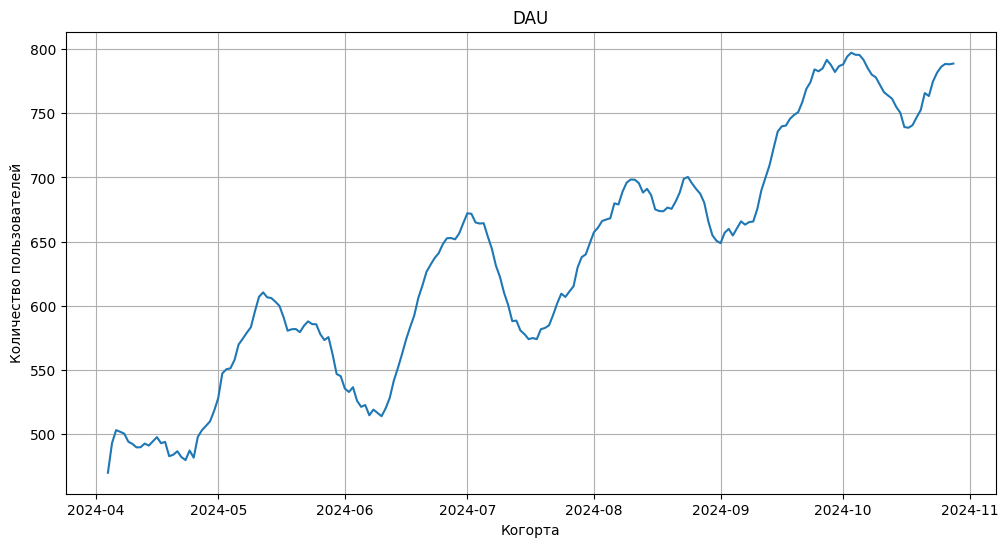

In [89]:
# визуализируем наши метрики на разных графиках ввиду масштаба
# mean_DAU
plt.figure(figsize=(12, 6))
plt.plot(df_dau['visit_day'].dt.to_timestamp(), df_dau['DAU_smooth'])
plt.title('DAU')
plt.xlabel('Когорта')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()


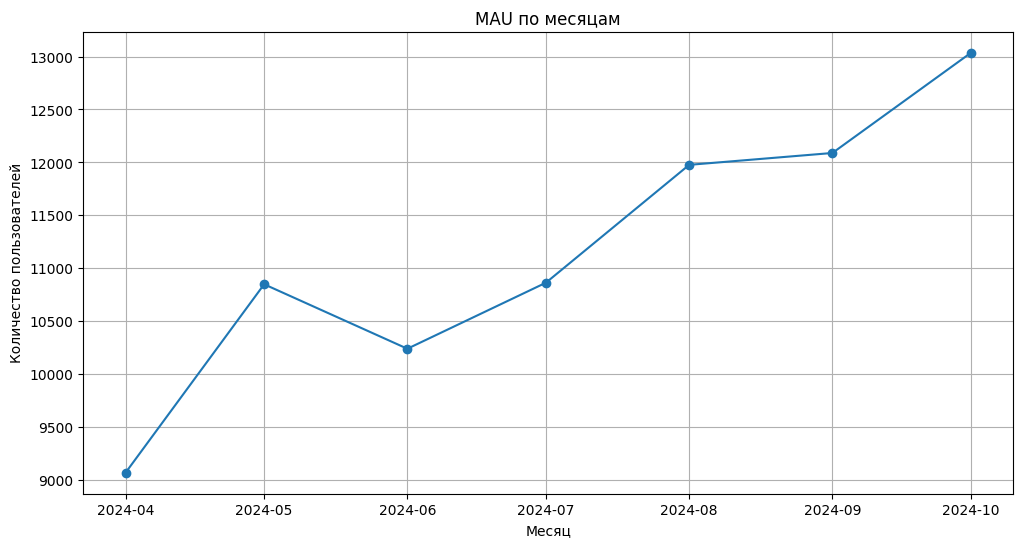

In [90]:
# MAU
plt.figure(figsize=(12, 6))
plt.plot(df_mau['visit_month'].dt.to_timestamp(), df_mau['MAU'], marker='o')
plt.title('MAU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

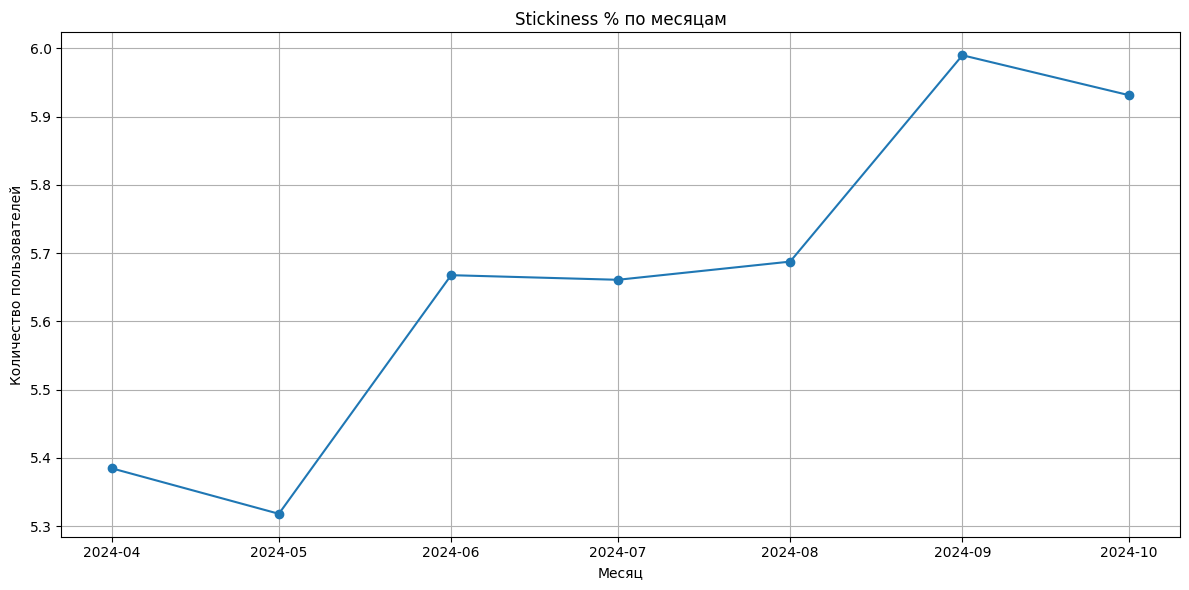

In [91]:
# stickiness
plt.figure(figsize=(12, 6))
plt.plot(df_stickiness['visit_month'].dt.to_timestamp(), df_stickiness['mean_stickiness'], marker='o')   
plt.title('Stickiness % по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.grid()
plt.tight_layout()
plt.show()

### Промежуточный вывод

DAU, MAU - уверенный рост на всем периоде анализа. MAU имеет просадку с мая по июнь, после ввода нового контента просадок не наблюдается.    
Stickiness низкий, около 5-6%. после ввода контента увеличивается, но всего на 1%. В целом показатель низкий.

**Задача 2**.   
В разрезе каждого месяца привлечения новых пользователей рассчитаем среднюю стоимость привлечения пользователя (CAC),    
а также значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.    
При расчёте LTV и ROI учитываем всех привлечённых пользователей когорты. Визуализируем метрики и сформулируем небольшой промежуточный вывод,    
сделав акцент на общей динамике изменения метрик с учётом появления нового контента в начале лета.

In [93]:
# фильтруем данные за 28 дней (0 - первый день)
profiles['lifetime'] = (profiles['visit_day'] - profiles['first_dt']).apply(lambda x: x.n)  
profiles['lifetime_orders'] = (profiles['purchase_day'] - profiles['first_dt']).apply(lambda x: x.n if pd.notna(x) else 0)
df_filtered = profiles[profiles['lifetime'] < 28].copy()

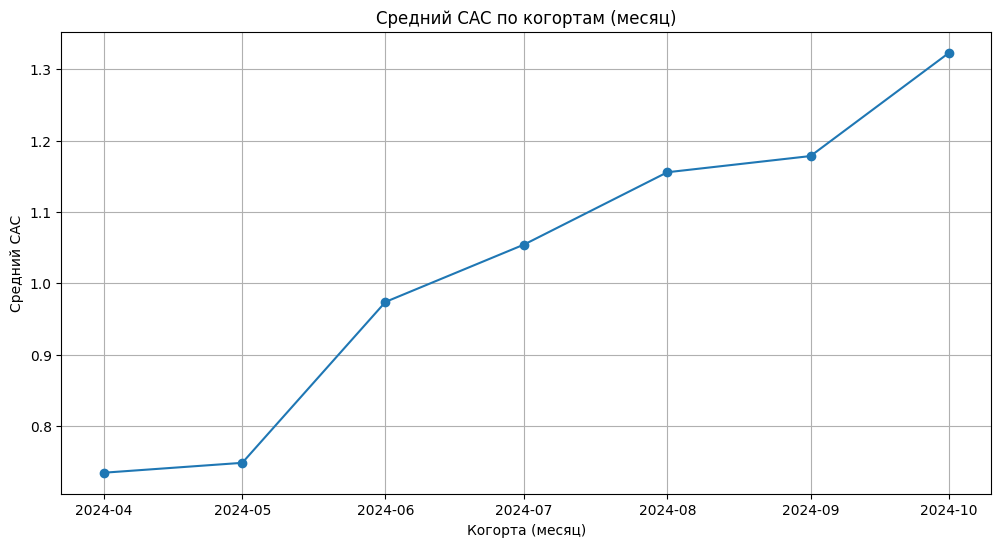

,first_month,mean_CAC
0,2024-04,0.734706
1,2024-05,0.748572
2,2024-06,0.973978
3,2024-07,1.054344
4,2024-08,1.155601
5,2024-09,1.178301
6,2024-10,1.323047


In [94]:
# средний CAC по когортам (месяц)
cac = df_cac.copy()
cac['first_month'] = cac['first_dt'].dt.to_timestamp().dt.to_period('M')
df_mean_cac = cac.groupby(['first_month']).agg(
    mean_CAC = ('CAC', 'mean')
).reset_index()

# визуализируем средний CAC по когортам
plt.figure(figsize=(12, 6))
plt.plot(df_mean_cac['first_month'].dt.to_timestamp(), df_mean_cac['mean_CAC'], marker='o')
plt.title('Средний CAC по когортам (месяц)')
plt.xlabel('Когорта (месяц)')
plt.ylabel('Средний CAC')
plt.grid()
plt.show()
df_mean_cac

In [95]:
df_filtered['first_month'] = df_filtered['first_dt'].dt.to_timestamp().dt.to_period('M')

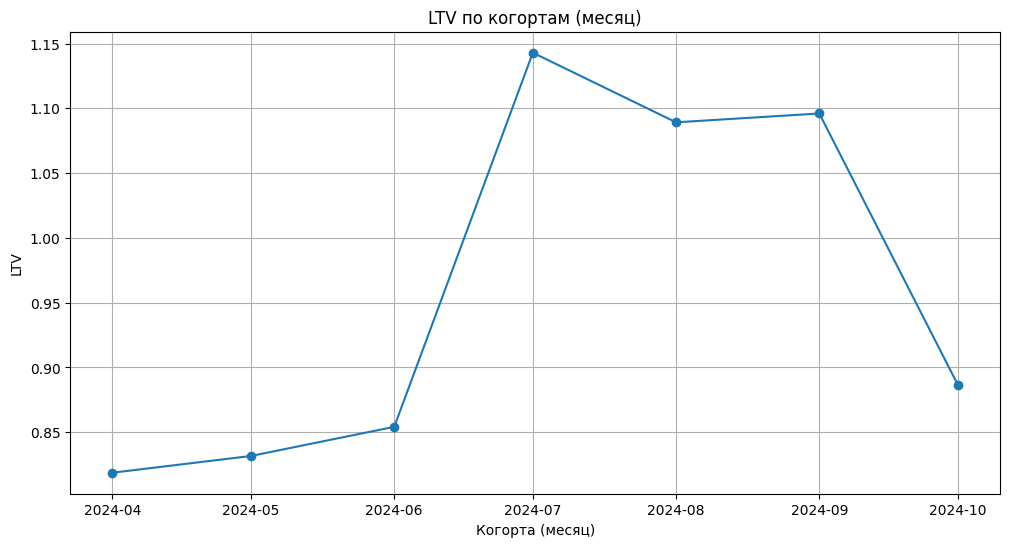

In [96]:
# посчитаем количество пользователей в когорте для рассчета LTV
df_filtered['revenue'] = df_filtered['revenue'].fillna(0)
df_filtered_ltv = df_filtered.groupby(['first_month'])\
    .agg(
        month_revenue = ('revenue', 'sum'),
        user_count_month = ('user_id', 'nunique')
    ).reset_index()

# посчитаем LTV                  
df_filtered_ltv['LTV'] = df_filtered_ltv['month_revenue'] / df_filtered_ltv['user_count_month']

# визуализируем LTV по когортам
plt.figure(figsize=(12, 6))
plt.plot(df_filtered_ltv['first_month'].dt.to_timestamp(), df_filtered_ltv['LTV'], marker='o')
plt.title('LTV по когортам (месяц)')
plt.xlabel('Когорта (месяц)')
plt.ylabel('LTV')
plt.grid()
plt.show()


In [97]:
df_filtered_ltv

,first_month,month_revenue,user_count_month,LTV
0,2024-04,7425.63,9069,0.818793
1,2024-05,8141.76,9789,0.831725
2,2024-06,7447.84,8719,0.854208
3,2024-07,9991.41,8742,1.142920
4,2024-08,10367.05,9518,1.089205
5,2024-09,10081.39,9198,1.096042
6,2024-10,8440.16,9520,0.886571


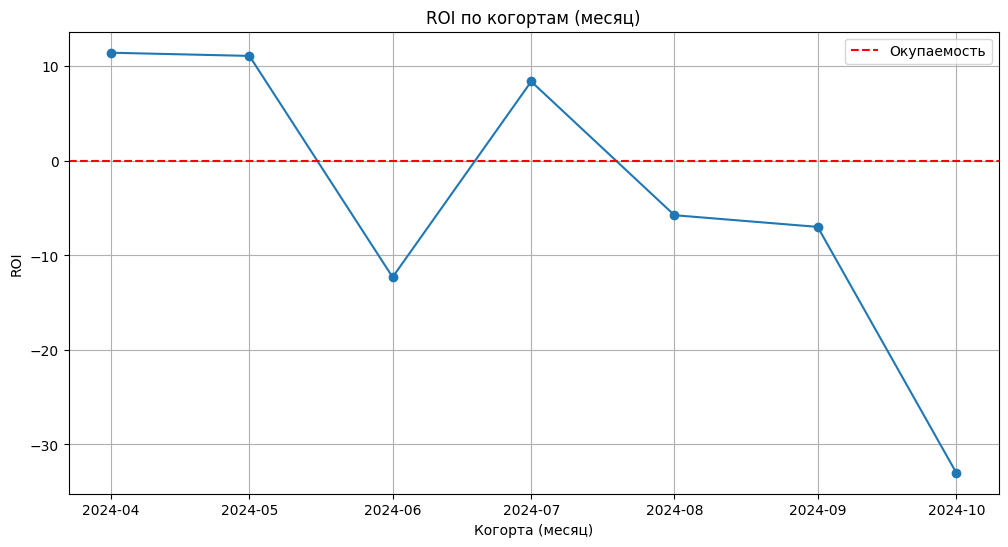

,first_month,month_revenue,user_count_month,LTV,mean_CAC,ROI
0,2024-04,7425.63,9069,0.818793,0.734706,11.444870
1,2024-05,8141.76,9789,0.831725,0.748572,11.108209
2,2024-06,7447.84,8719,0.854208,0.973978,-12.297015
3,2024-07,9991.41,8742,1.142920,1.054344,8.401051
4,2024-08,10367.05,9518,1.089205,1.155601,-5.745639
5,2024-09,10081.39,9198,1.096042,1.178301,-6.981212
6,2024-10,8440.16,9520,0.886571,1.323047,-32.990156


In [98]:
# посчитаем ROI для когорты
df_filtered_roi = df_filtered_ltv.merge(df_mean_cac, on='first_month', how='left')

# средний ROI по когортам (месяц)
df_filtered_roi['ROI'] = (df_filtered_roi['LTV'] - df_filtered_roi['mean_CAC']) / df_filtered_roi['mean_CAC'] * 100

# визуализируем средний ROI по когортам
plt.figure(figsize=(12, 6))
plt.plot(df_filtered_roi['first_month'].dt.to_timestamp(), df_filtered_roi['ROI'], marker='o')
plt.axhline(0, color='red', linestyle='--', label='Окупаемость')
plt.title('ROI по когортам (месяц)')
plt.xlabel('Когорта (месяц)')
plt.ylabel('ROI')
plt.grid()
plt.legend()
plt.show()
df_filtered_roi


### Промежуточный вывод

На протяжении всего срока анализа DAU показывает уверенный и стабильный рост. MAU  имеет небольшую просадку до июня, далее сильный рост.   
Показатель прилипчивости довольно волатилен, и имеет низкие показатели - 5-7%. После запуска нового контента показатель увеличвается, но затем принимает прежние значения.    
Средний CAC высокий и растет с каждым месяцем. LTV низкий. ROI имеет небольшие всплески, выше линии окупаемости, но большинство срока в сильных отрицательных значениях. 

## Анализ метрик в разрезе источника привлечения

Теперь необходимо разобраться, какие источники привлечения перспективны, а какие за 28 дней не окупились.

**Задача 1**.   
Определим самые популярные источники привлечения. Для этого:

- посчитаем общее число привлечённых пользователей для каждого источника
- визуализируем динамику набора новых пользователей по дням в каждом источнике
- рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения




In [99]:
# разберемся с каналами привлечения и их эффективностью
# посчитаем количество привлеченных пользователей по каналам
user_count_channel = profiles.groupby('first_channel').agg(
    total_users = ('user_id', 'nunique')
).reset_index()

In [100]:
user_count_channel

,first_channel,total_users
0,FaceBoom,24339
1,MediaTornado,12311
2,RocketSuperAds,12492
3,TipTop,15413


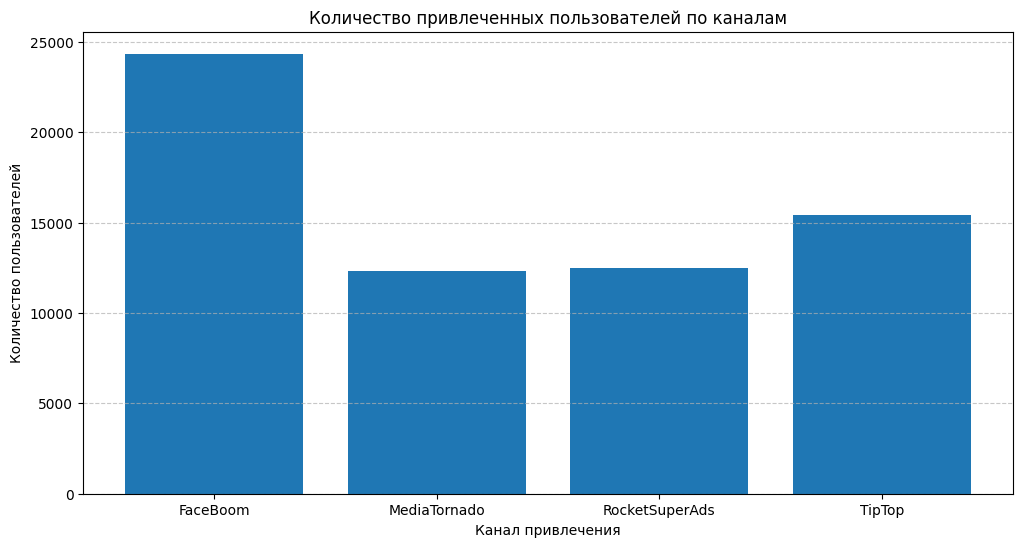

In [101]:
# визуализируем динамику набора
plt.figure(figsize=(12, 6))
plt.bar(user_count_channel['first_channel'], user_count_channel['total_users'])
plt.title('Количество привлеченных пользователей по каналам')
plt.xlabel('Канал привлечения')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()  

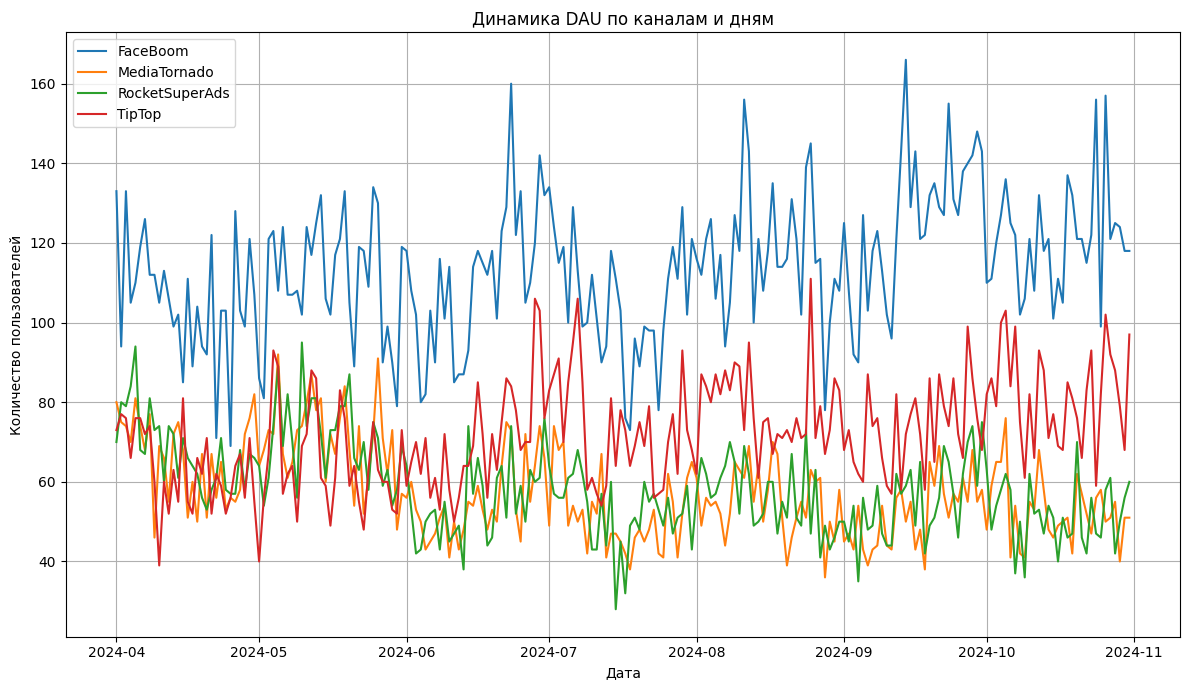

In [102]:
# динамика DAU по каналам
df_profiles_user_count = profiles.groupby(['first_dt', 'first_channel'])['user_id'].nunique().reset_index(name='user_count_dau')
df_profiles_user_count['month'] = df_profiles_user_count['first_dt'].dt.to_timestamp().dt.to_period('M')
dynamic_dau = df_profiles_user_count.pivot_table(
    index='first_dt',
    columns='first_channel',
    values='user_count_dau'
    )

# визуализируем динамику DAU по каналам и дням
plt.figure(figsize=(12, 7))
for channel in dynamic_dau.columns:
    plt.plot(dynamic_dau.index.to_timestamp(), dynamic_dau[channel], label=channel)
plt.title('Динамика DAU по каналам и дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


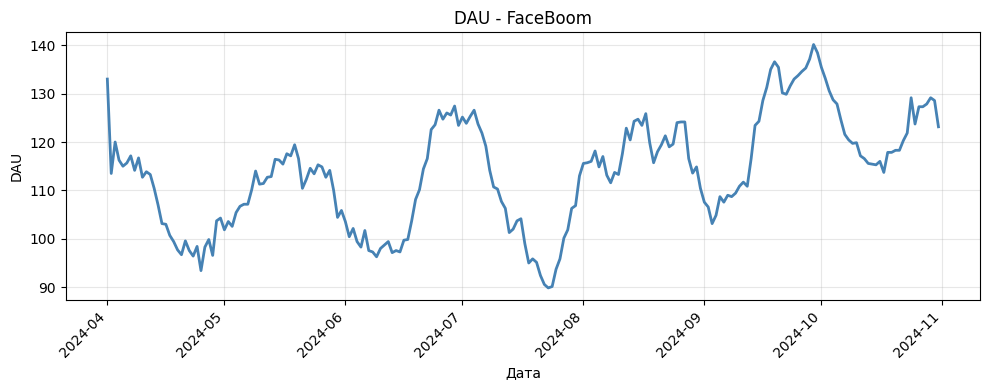

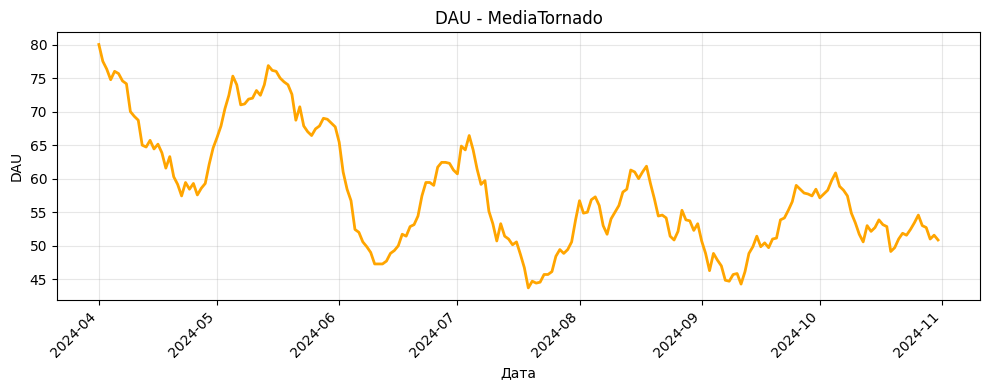

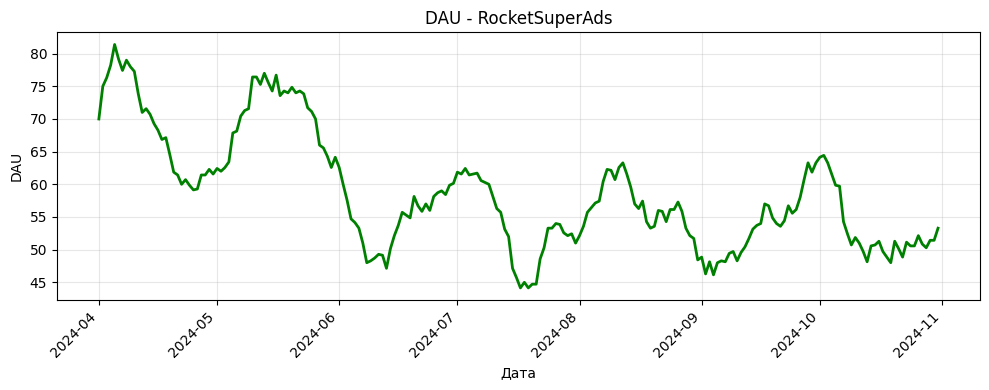

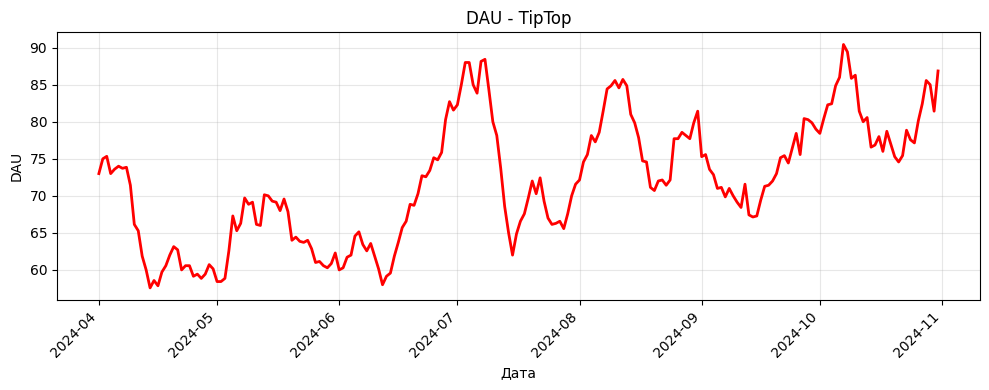

In [103]:
# сглаженные линии для динамики DAU по каналам и дням, отдельные графики для наглядности
channels = dynamic_dau.columns.tolist()
color = ['steelblue', 'orange', 'green', 'red']
for channel, col in zip(channels, color):
    plt.figure(figsize=(10, 4))
    
    channel_data = dynamic_dau[channel].dropna()
    
    if len(channel_data) > 0:
        # Только сглаженная линия
        smoothed = channel_data.rolling(window=7, min_periods=1).mean()
        
        plt.plot(channel_data.index.to_timestamp(), smoothed, 
                linewidth=2, color=col, label=f'{channel} (сглажено)')
        
        plt.title(f'DAU - {channel}', fontsize=12)
        plt.xlabel('Дата')
        plt.ylabel('DAU')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [124]:
# данные DAU 
dynamic_dau

first_channel,FaceBoom,MediaTornado,RocketSuperAds,TipTop
first_dt,,,,
2024-04-01,133.0,80.0,70.0,73.0
2024-04-02,94.0,75.0,80.0,77.0
2024-04-03,133.0,74.0,79.0,76.0
2024-04-04,105.0,70.0,84.0,66.0
2024-04-05,110.0,81.0,94.0,76.0
...,...,...,...,...
2024-10-27,121.0,51.0,61.0,92.0
2024-10-28,125.0,55.0,42.0,88.0
2024-10-29,124.0,40.0,50.0,79.0


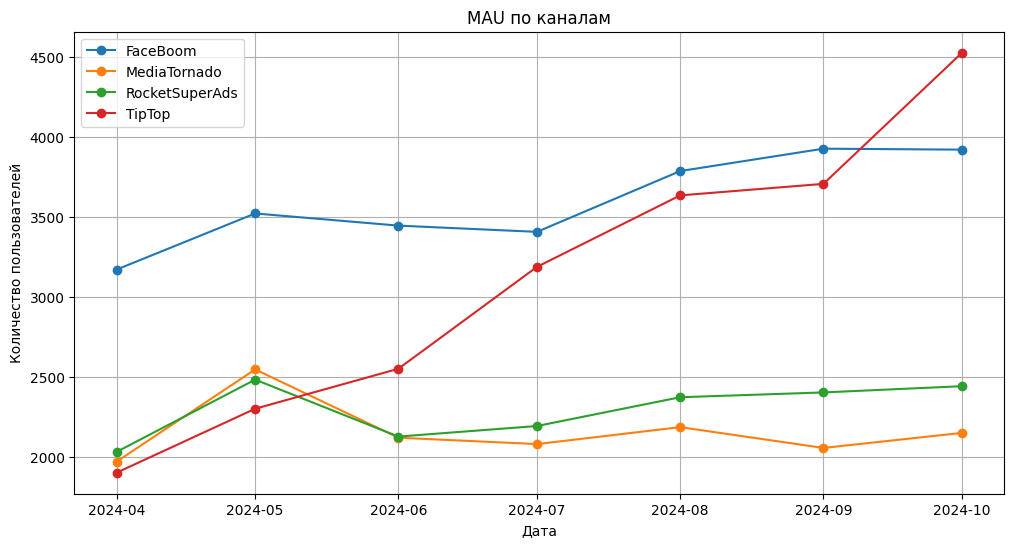

first_channel,FaceBoom,MediaTornado,RocketSuperAds,TipTop
visit_month,,,,
2024-04,3170.0,1969.0,2030.0,1900.0
2024-05,3521.0,2546.0,2482.0,2300.0
2024-06,3445.0,2119.0,2126.0,2550.0
2024-07,3406.0,2079.0,2192.0,3187.0
2024-08,3786.0,2185.0,2372.0,3634.0
2024-09,3926.0,2055.0,2402.0,3706.0
2024-10,3920.0,2149.0,2441.0,4526.0


In [107]:
# MAU по каналам
mau_user_count_channel = profiles.groupby(['visit_month', 'first_channel'])['user_id'].nunique().reset_index(name='user_count_mau')
pivot_user_count_channel = mau_user_count_channel.pivot_table(
    index='visit_month',
    columns='first_channel',
    values='user_count_mau'
    )  
# визуализируем MAU по каналам
plt.figure(figsize=(12, 6))
for channel in pivot_user_count_channel.columns:
    plt.plot(pivot_user_count_channel.index.to_timestamp(), pivot_user_count_channel[channel], marker='o', label=channel)
plt.title('MAU по каналам')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend()
plt.show()
pivot_user_count_channel

In [108]:
st_channel = df_profiles_user_count.merge(mau_user_count_channel, left_on=['month', 'first_channel'], right_on=['visit_month', 'first_channel'], how='left')

In [109]:
st_channel

,first_dt,first_channel,user_count_dau,month,visit_month,user_count_mau
0,2024-04-01,FaceBoom,133,2024-04,2024-04,3170
1,2024-04-01,MediaTornado,80,2024-04,2024-04,1969
2,2024-04-01,RocketSuperAds,70,2024-04,2024-04,2030
3,2024-04-01,TipTop,73,2024-04,2024-04,1900
4,2024-04-02,FaceBoom,94,2024-04,2024-04,3170
...,...,...,...,...,...,...
851,2024-10-30,TipTop,68,2024-10,2024-10,4526
852,2024-10-31,FaceBoom,118,2024-10,2024-10,3920
853,2024-10-31,MediaTornado,51,2024-10,2024-10,2149
854,2024-10-31,RocketSuperAds,60,2024-10,2024-10,2441


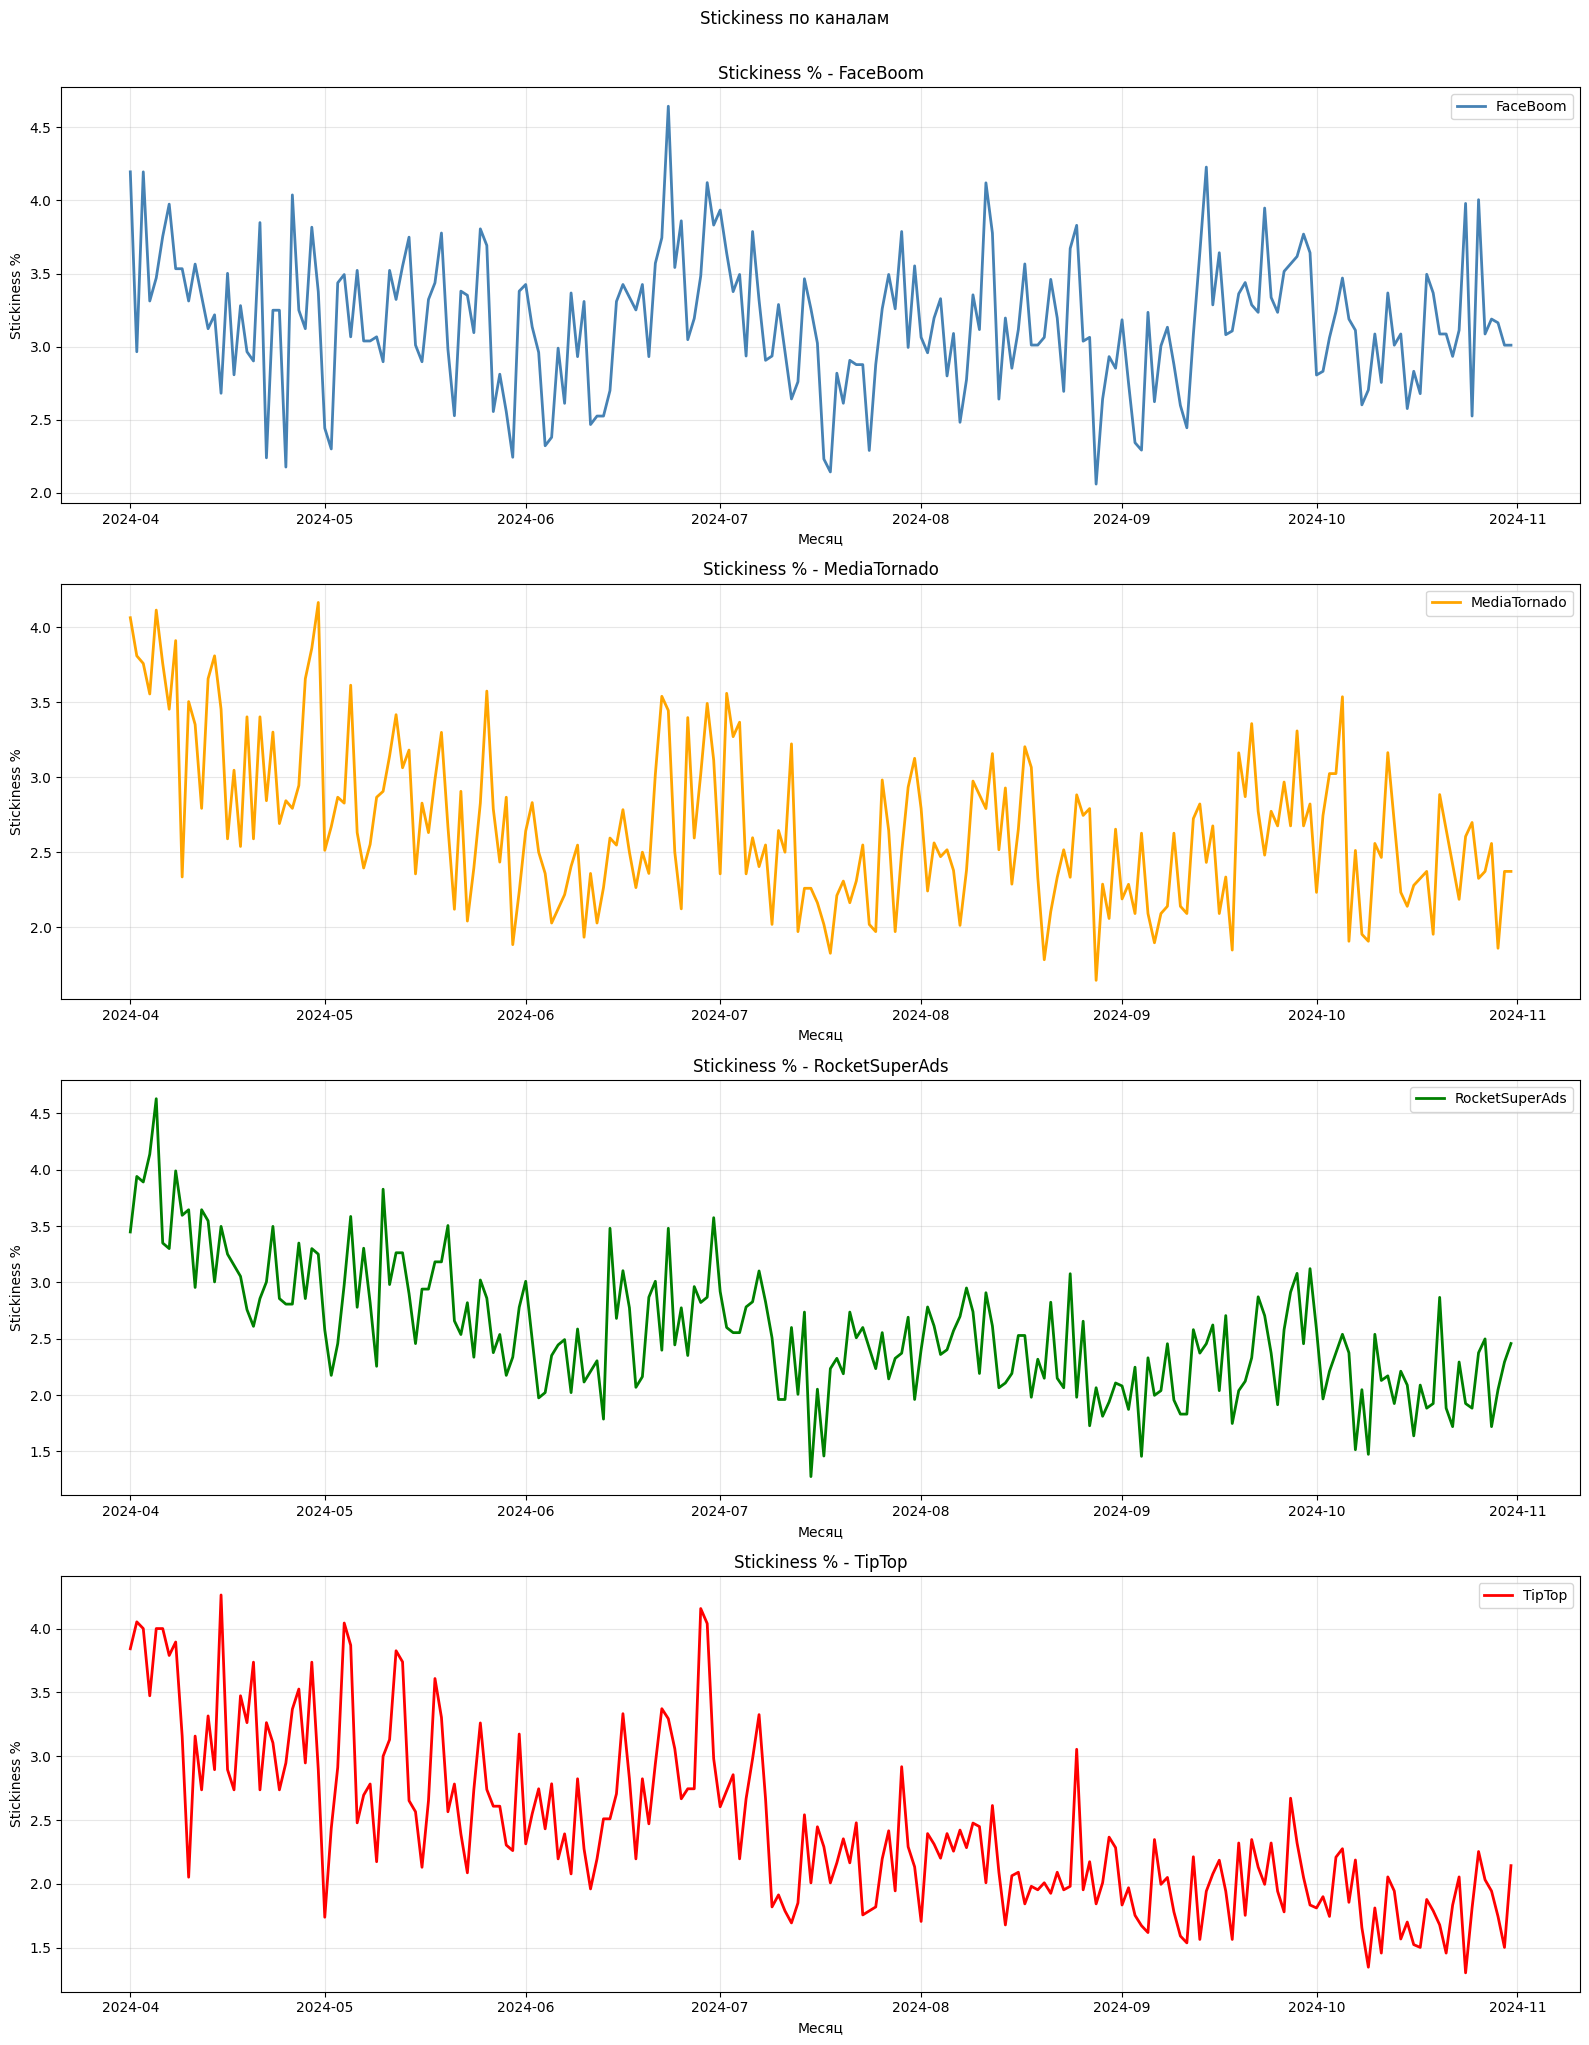

In [110]:
# рассчитаем Stickiness по каналам
st_channel['stickiness'] = st_channel['user_count_dau'] / st_channel['user_count_mau'] * 100
st_channel_pivot = st_channel.pivot_table(
    index='first_dt',
    columns='first_channel',
    values='stickiness'
)

channels = st_channel_pivot.columns.tolist()
color = ['steelblue', 'orange', 'green', 'red']
fig, axes = plt.subplots(4, 1, figsize=(16, 20)) 

for i, channel in enumerate(channels[:4]):  
    ax = axes[i]
    ax.plot(st_channel_pivot.index.to_timestamp(), st_channel_pivot[channel], 
            linewidth=2, color=color[i % len(color)], label=channel)
    ax.set_title(f'Stickiness % - {channel}')
    ax.set_ylabel('Stickiness %')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('Месяц')

plt.tight_layout()
plt.suptitle('Stickiness по каналам', y=1.02)
plt.show()

In [111]:
st_channel_pivot

first_channel,FaceBoom,MediaTornado,RocketSuperAds,TipTop
first_dt,,,,
2024-04-01,4.195584,4.062976,3.448276,3.842105
2024-04-02,2.965300,3.809040,3.940887,4.052632
2024-04-03,4.195584,3.758253,3.891626,4.000000
2024-04-04,3.312303,3.555104,4.137931,3.473684
2024-04-05,3.470032,4.113763,4.630542,4.000000
...,...,...,...,...
2024-10-27,3.086735,2.373197,2.498976,2.032700
2024-10-28,3.188776,2.559330,1.720606,1.944322
2024-10-29,3.163265,1.861331,2.048341,1.745471


**Задача 2**.    
Изучим динамику изменения метрик на 28-й день в разрезе источника.

Проведём анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:

- скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день)
- конверсию в покупку
- недельную динамику затрат на маркетинг по каждому источнику привлечения
- динамику среднего CAC, значений LTV и ROI

По результатам проведём анализ рекламных каналов. Дадим общую характеристику каждому рекламному каналу по рассчитанным метрикам. Укажем, какие рекламные каналы не вышли на уровень окупаемости за ожидаемый период, и предположим почему.

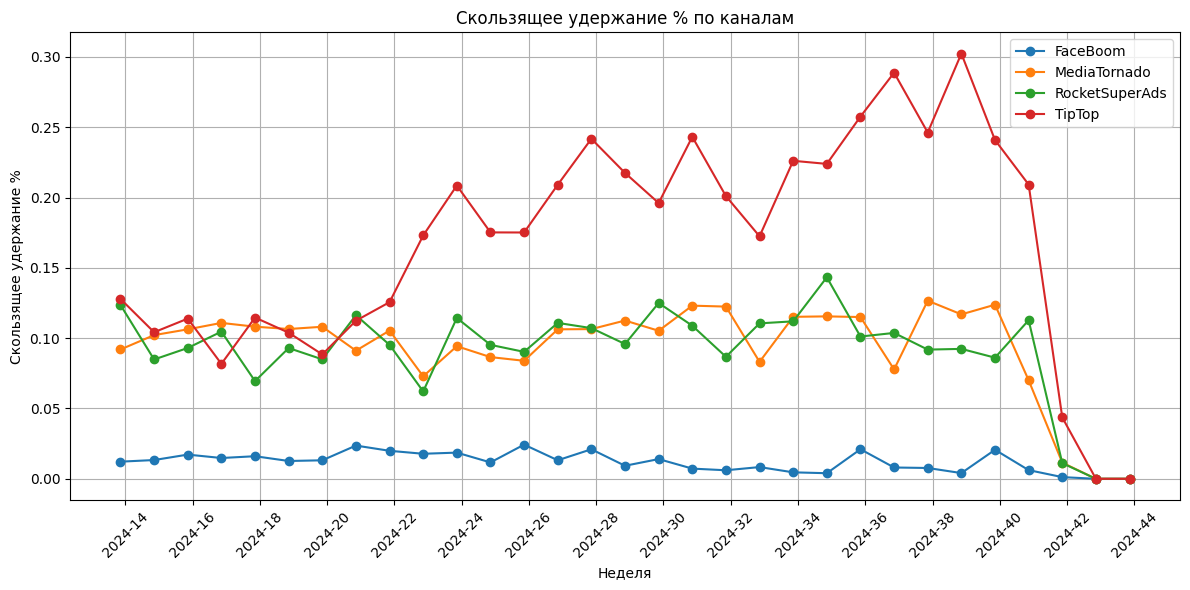

,week,first_channel,total_users,users_14_28,retention_rate
0,2024-04-01,FaceBoom,820,10,0.012195
1,2024-04-01,MediaTornado,522,48,0.091954
2,2024-04-01,RocketSuperAds,542,67,0.123616
3,2024-04-01,TipTop,516,66,0.127907
4,2024-04-08,FaceBoom,749,10,0.013351
...,...,...,...,...,...
119,2024-10-21,TipTop,577,0,0.000000
120,2024-10-28,FaceBoom,485,0,0.000000
121,2024-10-28,MediaTornado,197,0,0.000000
122,2024-10-28,RocketSuperAds,208,0,0.000000


In [112]:
# считаем скользящее удержание
df_age_sessions = profiles.copy()
df_age_sessions['week'] = df_age_sessions['first_dt'].dt.to_timestamp().dt.to_period('W').dt.start_time

# создаем признак активности в период 14-28 на уровне пользователя
df_user_activity = df_age_sessions.groupby(['user_id', 'week', 'first_channel']).agg(
    has_14_28_activity=('lifetime', lambda x: ((x >= 14) & (x <= 27)).any())
).reset_index()

# агрегируем
df_retention = df_user_activity.groupby(['week', 'first_channel']).agg(
    total_users=('user_id', 'count'),
    users_14_28=('has_14_28_activity', 'sum')
).reset_index()

df_retention['retention_rate'] = df_retention['users_14_28'] / df_retention['total_users']


# визуализируем скользящее удержание по каналам
plt.figure(figsize=(12, 6))
for channel in df_retention['first_channel'].unique():
    channel_data = df_retention[df_retention['first_channel'] == channel]
    plt.plot(channel_data['week'], channel_data['retention_rate'], marker='o', label=channel)
        
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%W'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))

plt.title('Скользящее удержание % по каналам')
plt.xlabel('Неделя')
plt.xticks(rotation = 45)
plt.ylabel('Скользящее удержание %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

df_retention


In [113]:
# посчитаем покупки пользователя
df_purchase = profiles[profiles['lifetime'] < 28][['user_id', 'first_dt', 'first_channel', 'revenue']]
df_purchase['week'] = df_purchase['first_dt'].dt.to_timestamp().dt.to_period('W')
df_purchase = df_purchase.groupby(['week', 'first_channel', 'user_id'])\
    .agg(
        revenue = ('revenue', 'sum')
    ).reset_index()
# создадим свойство, делал ли пользователь покупку
df_purchase['made_purchase'] = df_purchase['revenue'] > 0



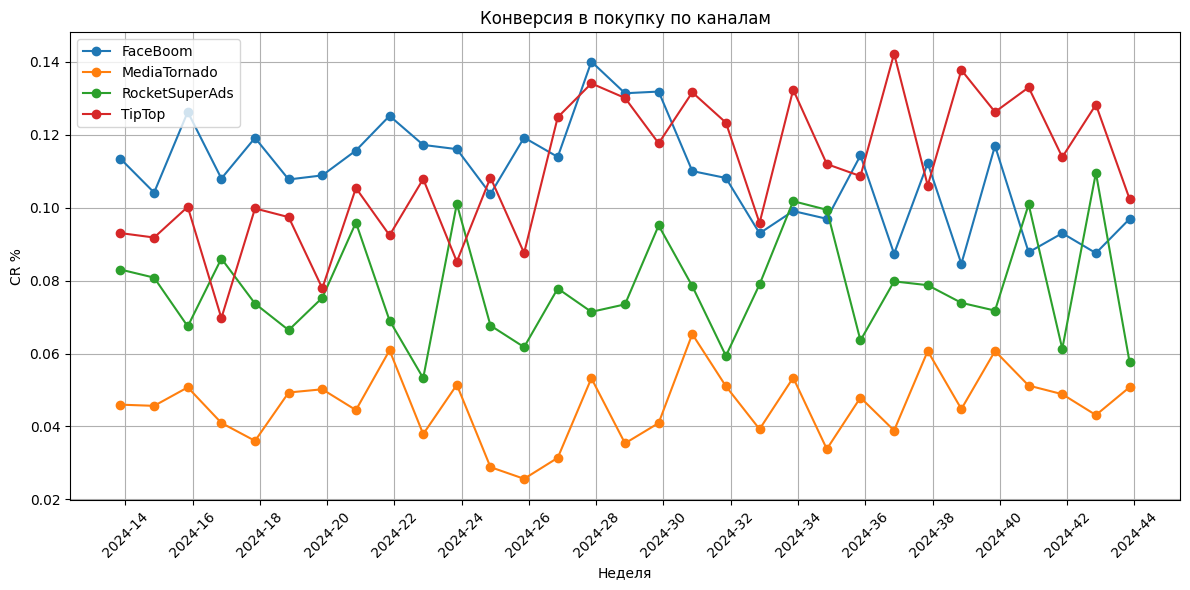

,week,first_channel,count_user,made_purchase_sum,cr_purchase
0,2024-04-01/2024-04-07,FaceBoom,820,93,0.113415
1,2024-04-01/2024-04-07,MediaTornado,522,24,0.045977
2,2024-04-01/2024-04-07,RocketSuperAds,542,45,0.083026
3,2024-04-01/2024-04-07,TipTop,516,48,0.093023
4,2024-04-08/2024-04-14,FaceBoom,749,78,0.104139
...,...,...,...,...,...
119,2024-10-21/2024-10-27,TipTop,577,74,0.128250
120,2024-10-28/2024-11-03,FaceBoom,485,47,0.096907
121,2024-10-28/2024-11-03,MediaTornado,197,10,0.050761
122,2024-10-28/2024-11-03,RocketSuperAds,208,12,0.057692


In [114]:
df_purchase_cr = df_purchase.groupby(['week', 'first_channel'])\
    .agg(
        count_user = ('user_id', 'nunique'),
        made_purchase_sum = ('made_purchase', 'sum')
    ).reset_index()
    
df_purchase_cr['cr_purchase'] = df_purchase_cr['made_purchase_sum'] / df_purchase_cr['count_user']

# визуализируем CR по каналам
plt.figure(figsize=(12, 6))
for channel in df_purchase_cr['first_channel'].unique():
    channel_data = df_purchase_cr[df_purchase_cr['first_channel'] == channel]
    plt.plot(channel_data['week'].dt.to_timestamp(), channel_data['cr_purchase'], marker='o', label=channel)
    
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%W'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))

plt.title('Конверсия в покупку по каналам')
plt.xlabel('Неделя')
plt.xticks(rotation=45)
plt.ylabel('CR %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

df_purchase_cr

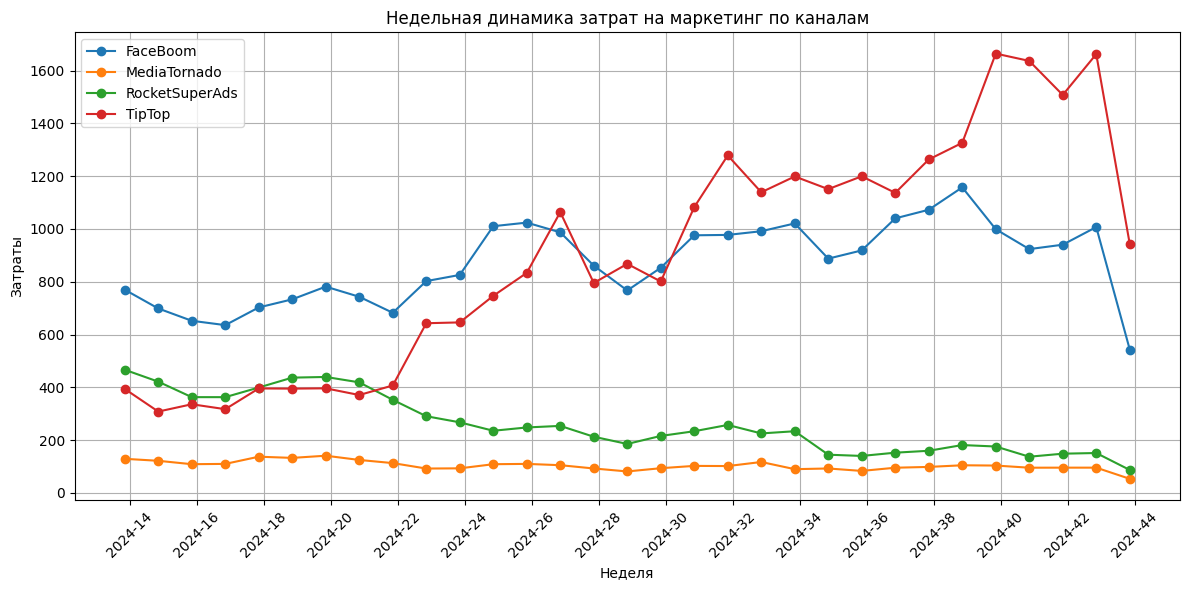

,week,channel,costs
0,2024-04-01,FaceBoom,769.875901
1,2024-04-01,MediaTornado,129.318322
2,2024-04-01,RocketSuperAds,466.650000
3,2024-04-01,TipTop,393.989381
4,2024-04-08,FaceBoom,698.872741
...,...,...,...
119,2024-10-21,TipTop,1662.445517
120,2024-10-28,FaceBoom,543.431929
121,2024-10-28,MediaTornado,53.571526
122,2024-10-28,RocketSuperAds,87.125000


In [115]:
# недельная динамика затрат на маркетинг по каналам
df_costs_grouped = df_costs.groupby(['dt', 'channel'])['costs'].sum().reset_index()
df_costs_grouped['week'] = df_costs_grouped['dt'].dt.to_timestamp().dt.to_period('W').dt.start_time
df_costs_weekly = df_costs_grouped.groupby(['week', 'channel'])['costs'].sum().reset_index()

# визуализируем недельную динамику затрат на маркетинг по каналам
plt.figure(figsize=(12, 6))
for channel in df_costs_weekly['channel'].unique():
    channel_data = df_costs_weekly[df_costs_weekly['channel'] == channel]
    plt.plot(channel_data['week'], channel_data['costs'], marker='o', label=channel) 
    
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%W'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))

plt.title('Недельная динамика затрат на маркетинг по каналам')
plt.xlabel('Неделя')
plt.xticks(rotation=45)
plt.ylabel('Затраты')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

df_costs_weekly

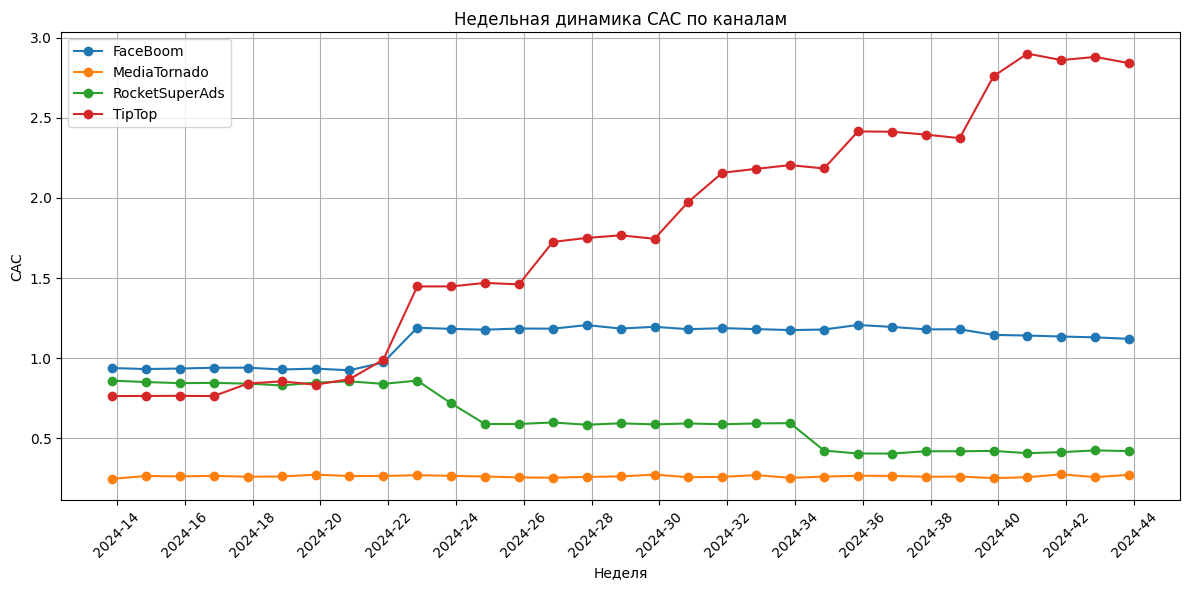

,first_week,first_channel,mean_cac
0,2024-04-01/2024-04-07,FaceBoom,0.938515
1,2024-04-01/2024-04-07,MediaTornado,0.247445
2,2024-04-01/2024-04-07,RocketSuperAds,0.859847
3,2024-04-01/2024-04-07,TipTop,0.763548
4,2024-04-08/2024-04-14,FaceBoom,0.932477
...,...,...,...
119,2024-10-21/2024-10-27,TipTop,2.880036
120,2024-10-28/2024-11-03,FaceBoom,1.120494
121,2024-10-28/2024-11-03,MediaTornado,0.272634
122,2024-10-28/2024-11-03,RocketSuperAds,0.420402


In [116]:
# неделная динамика CAC по каналам
df_cac_weekly = profiles[profiles['lifetime'] < 28][['user_id', 'first_dt', 'first_channel', 'CAC']]

df_cac_weekly['first_week'] = df_cac_weekly['first_dt'].dt.to_timestamp().dt.to_period('W')
df_cac_weekly = df_cac_weekly.groupby(['first_week', 'first_channel'])\
    .agg(
        mean_cac = ('CAC', 'mean')
    ).reset_index()
    
# визуализируем недельную динамику CAC по каналам
plt.figure(figsize=(12, 6))
for channel in df_cac_weekly['first_channel'].unique():
    channel_data = df_cac_weekly[df_cac_weekly['first_channel'] == channel]
    plt.plot(channel_data['first_week'].dt.to_timestamp(), channel_data['mean_cac'], marker='o', label=channel)
 
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%W'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))

plt.title('Недельная динамика CAC по каналам')
plt.xlabel('Неделя')
plt.xticks(rotation=45)
plt.ylabel('CAC')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

df_cac_weekly

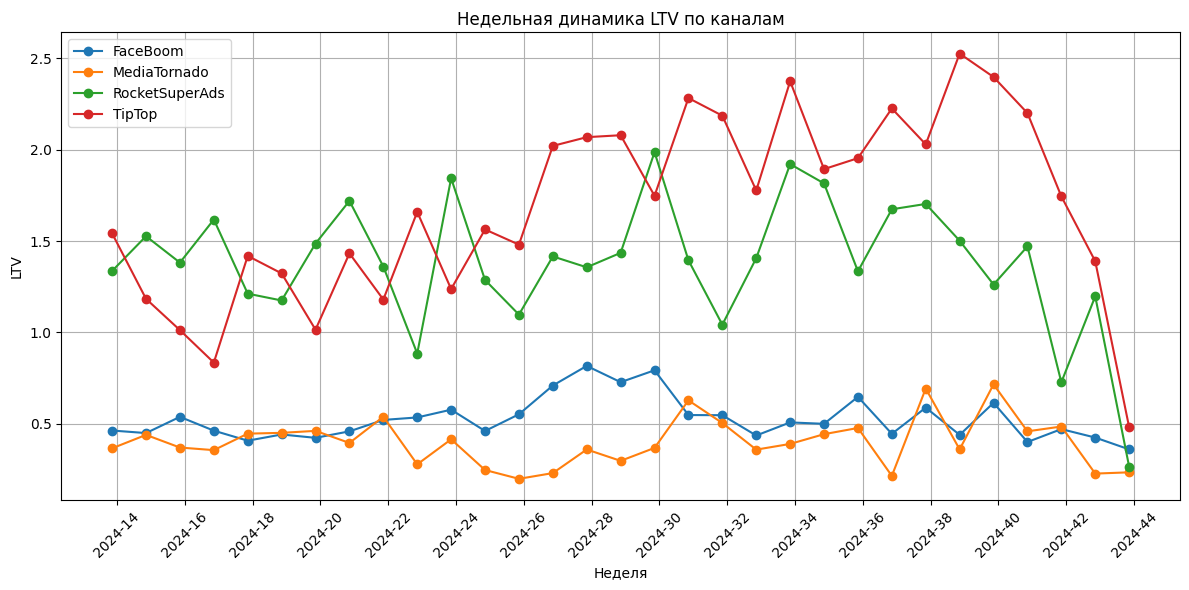

In [117]:
# недельная динамика LTV по каналам
df_ltv_weekly = profiles[profiles['lifetime'] < 28][['user_id', 'first_dt', 'first_channel', 'revenue']]
df_ltv_weekly['first_week'] = df_ltv_weekly['first_dt'].dt.to_timestamp().dt.to_period('W')
df_ltv_weekly = df_ltv_weekly.groupby(['first_week', 'first_channel'])\
    .agg(
        total_revenue = ('revenue', 'sum'),
        user_count_week = ('user_id', 'nunique')
    ).reset_index()

df_ltv_weekly['LTV'] = df_ltv_weekly['total_revenue'] / df_ltv_weekly['user_count_week']

# визуализируем недельную динамику LTV по каналам
plt.figure(figsize=(12, 6))
for channel in df_ltv_weekly['first_channel'].unique():
    channel_data = df_ltv_weekly[df_ltv_weekly['first_channel'] == channel]
    plt.plot(channel_data['first_week'].dt.start_time, channel_data['LTV'], marker='o', label=channel)
    
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%W'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))

plt.title('Недельная динамика LTV по каналам')
plt.xlabel('Неделя')
plt.xticks(rotation=45) 
plt.ylabel('LTV')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [118]:
df_ltv_weekly

,first_week,first_channel,total_revenue,user_count_week,LTV
0,2024-04-01/2024-04-07,FaceBoom,380.36,820,0.463854
1,2024-04-01/2024-04-07,MediaTornado,191.43,522,0.366724
2,2024-04-01/2024-04-07,RocketSuperAds,724.33,542,1.336402
3,2024-04-01/2024-04-07,TipTop,795.40,516,1.541473
4,2024-04-08/2024-04-14,FaceBoom,337.06,749,0.450013
...,...,...,...,...,...
119,2024-10-21/2024-10-27,TipTop,801.69,577,1.389411
120,2024-10-28/2024-11-03,FaceBoom,174.98,485,0.360784
121,2024-10-28/2024-11-03,MediaTornado,46.36,197,0.235330
122,2024-10-28/2024-11-03,RocketSuperAds,55.33,208,0.266010


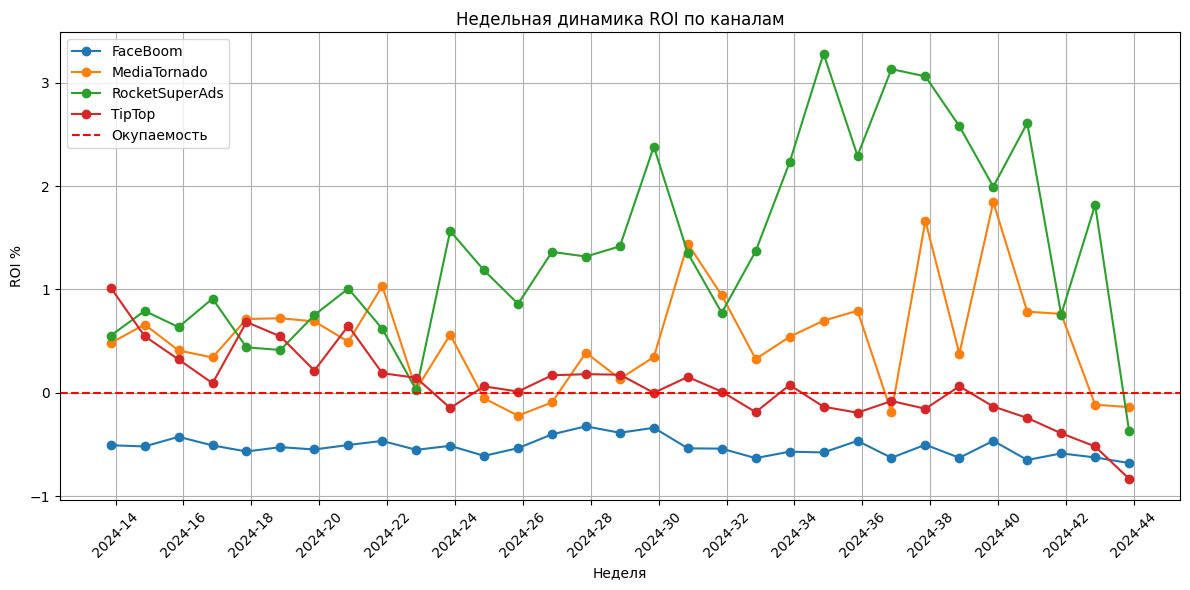

,first_week,first_channel,total_revenue,user_count_week,LTV,mean_cac,ROI
0,2024-04-01/2024-04-07,FaceBoom,380.36,820,0.463854,0.938515,-0.505758
1,2024-04-01/2024-04-07,MediaTornado,191.43,522,0.366724,0.247445,0.482045
2,2024-04-01/2024-04-07,RocketSuperAds,724.33,542,1.336402,0.859847,0.554233
3,2024-04-01/2024-04-07,TipTop,795.40,516,1.541473,0.763548,1.018830
4,2024-04-08/2024-04-14,FaceBoom,337.06,749,0.450013,0.932477,-0.517400
...,...,...,...,...,...,...,...
119,2024-10-21/2024-10-27,TipTop,801.69,577,1.389411,2.880036,-0.517572
120,2024-10-28/2024-11-03,FaceBoom,174.98,485,0.360784,1.120494,-0.678014
121,2024-10-28/2024-11-03,MediaTornado,46.36,197,0.235330,0.272634,-0.136827
122,2024-10-28/2024-11-03,RocketSuperAds,55.33,208,0.266010,0.420402,-0.367249


In [119]:
# считаем ROI по каналам
df_roi_weekly = df_ltv_weekly.merge(df_cac_weekly, on=['first_week', 'first_channel'], how='left')
df_roi_weekly['ROI'] = (df_roi_weekly['LTV'] - df_roi_weekly['mean_cac']) / df_roi_weekly['mean_cac']

# визуализируем недельную динамику ROI по каналам
plt.figure(figsize=(12, 6))
for channel in df_roi_weekly['first_channel'].unique():
    channel_data = df_roi_weekly[df_roi_weekly['first_channel'] == channel]
    plt.plot(channel_data['first_week'].dt.to_timestamp(), channel_data['ROI'], marker='o', label=channel)
    
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%W'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval = 2))

plt.axhline(0, color='red', linestyle='--', label='Окупаемость')
plt.title('Недельная динамика ROI по каналам')
plt.xlabel('Неделя')
plt.xticks(rotation=45)
plt.ylabel('ROI %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

df_roi_weekly

### Промежуточные выводы

Самый высокий показатель количества привлеченных пользователей имеет канал FaceBoom, на втором месте TipTop. Показатели DAU так же для этих каналов имеют высокие, но волатильные показатели. Каналы MediaTornado и RocketSuperAds напротив, высокие показатели на старте и ьыстро снижаются. MAU аналогичен.   
Прилипчивость по всем каналам имеет очень низкие показатели, менее 5%. FaceBoom - 2-4.6%, MediaTornado после ввода нового контента потерял в метрике 1%, оставаясь на уровне 1-3.5% до конца периода. RocketSuperAds и TipTop с 4.5% снижаются до 1,5% на всем периоде анализа.      
Скользящее удержание низкое, MediaTornado/RocketSuperAds в районе 10%, менее 3% у FaceBoom, TipTop после ввода нового окнтента растет с 10% до 25-30%. 
Каналы показывают очень низкое удержание пользователей, аудитория нецелевая.   
Конверсия в покупку очень низкаЯ, MediaTornado и RocketSuperAds - 5-10%, FaceBoom и TipTop - 10-14%.   
Динамика затрат на маркетинг с вводом нового контента сильно выросла у каналов FaceBoom и TipTop.   
Недельная динамика ROI говорит о том, что только два канала выходят на окупаемость - RocketSuperAds и MediaTornado.

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости:

- рассчитаем и визуализируем в виде тепловой карты значения ROI за больший период, например за 8–10 недель
- разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используем недели
- сделаем вывод о том, за какой период окупаются вложения в эти источники

In [120]:
channels_list = ['FaceBoom', 'TipTop']

df_roi_period_10 = df_orders.copy()

df_v = df_visits.groupby('user_id').agg(
    first_dt = ('session_start', 'min'),
    first_channel = ('channel', 'first')
).reset_index()

df_roi_period_10 = df_roi_period_10.merge(df_v, on='user_id')

df_roi_period_10['first_week'] = df_roi_period_10['first_dt'].dt.to_period('W').dt.to_timestamp()
df_roi_period_10['week'] = df_roi_period_10['event_dt'].dt.to_period('W').dt.to_timestamp()

df_roi_period_10['n_period'] = (df_roi_period_10['week'] - df_roi_period_10['first_week']).apply(lambda x: x.days) // 7

df_roi_period_10 = df_roi_period_10.groupby(['first_channel', 'first_week', 'n_period'])['revenue'].sum().reset_index()

df_roi_period_10 = df_roi_period_10.sort_values(by = ['first_channel', 'n_period'])

df_roi_period_10['cum_rev'] = df_roi_period_10.groupby(['first_channel', 'first_week'])['revenue'].cumsum()

cohort_size = profiles.copy()
cohort_size = cohort_size.groupby(['first_channel', 'first_week']).agg(
    count_user = ('user_id', 'nunique'),
    mean_cac = ('CAC', 'mean')
).reset_index()
cohort_size = cohort_size[['first_channel', 'first_week', 'count_user', 'mean_cac']]

df_roi_period_10 = df_roi_period_10.merge(cohort_size, on = ['first_channel', 'first_week'])
df_roi_period_10['ltv'] = df_roi_period_10.cum_rev / df_roi_period_10.count_user

df_roi_period_10['roi'] = (df_roi_period_10['ltv'] - df_roi_period_10['mean_cac']) / df_roi_period_10['mean_cac']

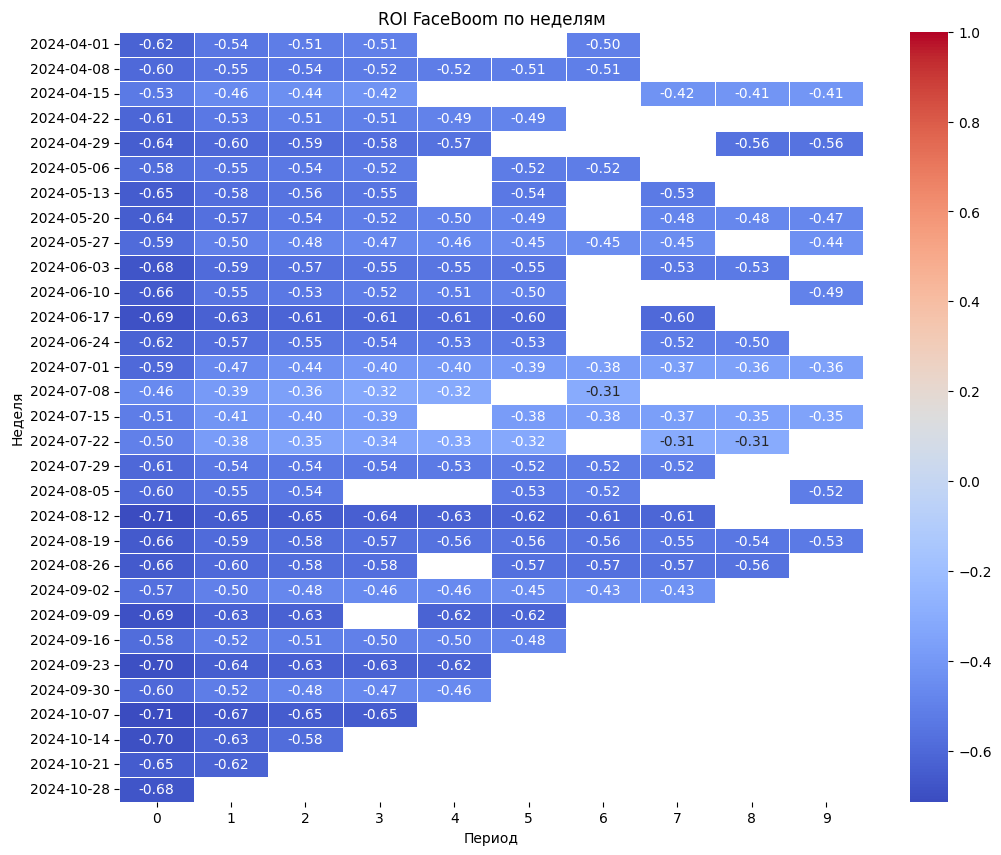

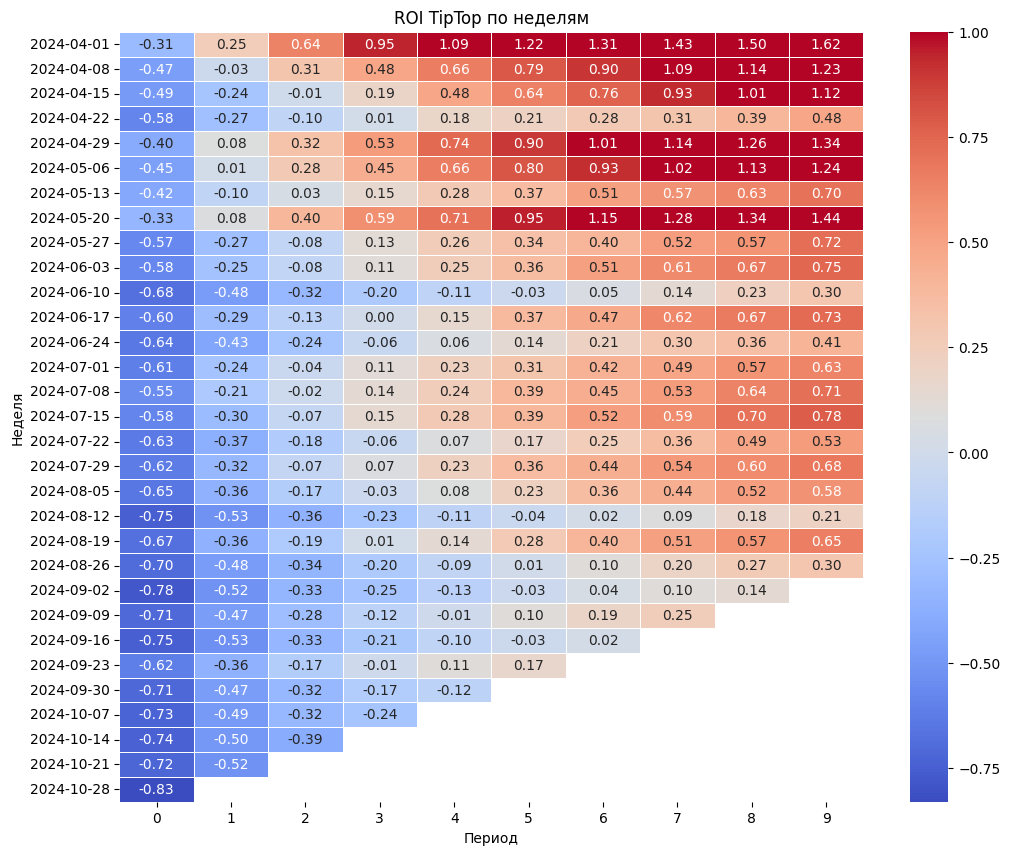

In [121]:
for ch in channels_list:
    data = df_roi_period_10.query('first_channel == @ch').query('n_period < 10')

    data_pivot = data.pivot(index='first_week', columns='n_period', values='roi')
    data_pivot.index = np.datetime_as_string(data_pivot.index, unit='D')

    # Строим heatmap
    plt.figure(figsize=(12, 10))

    sns.heatmap(data_pivot,
            annot=True,
            fmt='.2f',
            linewidths=0.5, 
            linecolor='white',
            vmax=1, 
            cmap='coolwarm',
    )

    plt.title(f'ROI {ch} по неделям')
    plt.xlabel('Период')
    plt.ylabel('Неделя')
    plt.show()

### Промежуточные выводы

Канал FaceBoom показывает окупаемость лишь в начале исследуемого периода. После ввода нового контента окупаемость снижается, сроки окупаемости сильно растут.    
Канал TipTop не выходит на окупаемость на протяжении всег орассматриваемого периода. 

## Выводы и рекомендации


Аудитория продукта нецелевая и имеет слабое удержание. Конверсия в покупку слабая, возможно платежеспособность низкая.   
Маркетинговые затраты на все каналы высокие и малоэффективные. По двум каналам FaceBoom и TipTop затраты превышают выручку. Пользователи праткически не задерживаются в проекте.    
Можно предположить, что аудитория не соответствует продукту, и каналы настроены неверно. Отделу маркетинга следует пересмотреть стратегию привлечения пользователей, и бюджет на привлечение. 
